#### Connect Python to Databricks

In [1]:
import os
import pandas as pd
import numpy as np

from dotenv import load_dotenv
from databricks import sql

load_dotenv()

HOST = os.getenv("DATABRICKS_SERVER_HOSTNAME")
HTTP_PATH = os.getenv("DATABRICKS_HTTP_PATH")


def get_connection():
    return sql.connect(
        server_hostname=HOST,
        http_path=HTTP_PATH,
        auth_type="databricks-oauth",
        user_agent_entry="zomato-statistical-testing"
    )


def query_df(query: str) -> pd.DataFrame:
    with get_connection() as conn:
        with conn.cursor() as cursor:
            cursor.execute(query)
            rows = cursor.fetchall()
            columns = [d[0] for d in cursor.description]

    return pd.DataFrame(rows, columns=columns)

### All the Engineered Features From Dataset

#### 1. Restaurant Features

In [2]:
restaurant_features = query_df("""
SELECT
    restaurant_key,
    city_key,
    locality_key,

    dining_rating,
    delivery_rating,
    dining_votes,
    delivery_votes,

    quality_score,
    engagement_score,

    menu_item_count,
    avg_item_votes,
    bestseller_rate,

    avg_item_price,
    restaurant_price_position

FROM zomato_market_intelligence.silver.fe_restaurant_segments
""")

#### 2. Locality Expansion Features

In [3]:
market_features = query_df("""
SELECT
    city_key,
    locality_key,

    restaurant_count,

    locality_quality_score,
    locality_engagement_score,

    cuisine_diversity_count,
    cuisine_hhi,

    avg_item_price,
    median_item_price,
    price_band_diversity,

    max_positive_cuisine_gap,
    avg_positive_cuisine_gap,

    max_positive_pricing_gap,
    avg_positive_pricing_gap,

    engineered_saturation_index,

    quality_component,
    engagement_component,
    coverage_opportunity_component,
    cuisine_component,
    pricing_component,

    engineered_expansion_score,
    expansion_priority,
    market_evidence_score

FROM zomato_market_intelligence.silver.fe_market_expansion
""")

#### 3. Menu Features

In [4]:
menu_features = query_df("""
SELECT
    restaurant_key,
    menu_item_key,
    cuisine_key,

    item_price,
    item_votes,

    item_votes_log,
    item_popularity_score,
    item_value_efficiency

FROM zomato_market_intelligence.silver.fe_menu_item
""")

CloudFetch download slower than threshold: 0.0595 MB/s (threshold: 0.1 MB/s) from https://us-east-2.storage.cloud.databricks.com/api/2.0/fs/files/WorkspaceInternal/Jobs/sql/2026-08-11/11/results_2026-08-11T11:20:43Z_bf38616b-b0d7-453f-9b69-da56aa0523c2?v=1&workspaceId=7474656098839398&wkt=cp&X-Databricks-TTL=899983&X-Databricks-Consumer-Network-Zone=internet&sn=ohio-prod&X-Databricks-Key-Version=01f193dd-1f66-19d1-97bf-31ab9e12714a&X-Databricks-Issued=20260811T122510Z&X-Databricks-Signature=AWEwaxLBpMsEWWpaCIAxLTED0r6OK228Rg2VuxTXj4OjMNr0MA


#### Pulling City / Locality Labels

In [5]:
cities = query_df("""
SELECT
    city_key,
    city_name
FROM zomato_market_intelligence.silver.dim_city
""")

localities = query_df("""
SELECT
    locality_key,
    city_key,
    locality_name
FROM zomato_market_intelligence.silver.dim_locality
""")

restaurant_features = restaurant_features.merge(
    cities,
    on="city_key",
    how="left"
)

restaurant_features = restaurant_features.merge(
    localities,
    on=["locality_key", "city_key"],
    how="left"
)

market_features = market_features.merge(
    cities,
    on="city_key",
    how="left"
)

market_features = market_features.merge(
    localities,
    on=["locality_key", "city_key"],
    how="left"
)

#### Data-Type and Statistical Audit

In [6]:
numeric_restaurant = [
    "dining_rating",
    "delivery_rating",
    "dining_votes",
    "delivery_votes",
    "quality_score",
    "engagement_score",
    "menu_item_count",
    "avg_item_votes",
    "bestseller_rate",
    "avg_item_price",
    "restaurant_price_position"
]

numeric_market = [
    "restaurant_count",
    "locality_quality_score",
    "locality_engagement_score",
    "cuisine_diversity_count",
    "cuisine_hhi",
    "avg_item_price",
    "median_item_price",
    "price_band_diversity",
    "max_positive_cuisine_gap",
    "avg_positive_cuisine_gap",
    "max_positive_pricing_gap",
    "avg_positive_pricing_gap",
    "engineered_saturation_index",
    "quality_component",
    "engagement_component",
    "coverage_opportunity_component",
    "cuisine_component",
    "pricing_component",
    "engineered_expansion_score",
    "market_evidence_score"
]

for col in numeric_restaurant:
    restaurant_features[col] = pd.to_numeric(
        restaurant_features[col],
        errors="coerce"
    )

for col in numeric_market:
    market_features[col] = pd.to_numeric(
        market_features[col],
        errors="coerce"
    )

#### Distribution Diagnostics

In [7]:
distribution_report = pd.DataFrame({
    "mean": restaurant_features[numeric_restaurant].mean(),
    "median": restaurant_features[numeric_restaurant].median(),
    "std": restaurant_features[numeric_restaurant].std(),
    "skewness": restaurant_features[numeric_restaurant].skew(),
    "missing_pct": (
        restaurant_features[numeric_restaurant]
        .isna()
        .mean() * 100
    )
})

distribution_report

,mean,median,std,skewness,missing_pct
dining_rating,3.792569,3.800000,0.413889,-0.507373,32.275711
delivery_rating,3.957464,4.000000,0.269369,-0.553905,2.516411
dining_votes,113.086433,11.000000,199.508142,2.282406,0.000000
delivery_votes,143.319475,0.000000,263.823289,1.774878,0.000000
quality_score,0.585920,0.631917,0.209019,-0.412596,0.000000
engagement_score,0.476913,0.499452,0.320354,-0.171402,0.000000
menu_item_count,105.764770,86.000000,81.243110,1.792111,0.000000
avg_item_votes,26.428325,10.384100,55.328201,6.098788,0.000000
bestseller_rate,0.270359,0.222222,0.204471,1.830548,0.000000
avg_item_price,233.476385,216.859073,111.989449,1.914015,0.000000


In [8]:
market_distribution_report = pd.DataFrame({
    "mean": market_features[numeric_market].mean(),
    "median": market_features[numeric_market].median(),
    "std": market_features[numeric_market].std(),
    "skewness": market_features[numeric_market].skew(),
    "missing_pct": (
        market_features[numeric_market]
        .isna()
        .mean() * 100
    )
})

market_distribution_report

,mean,median,std,skewness,missing_pct
restaurant_count,2.778116,2.000000,2.664584,2.449389,0.000000
locality_quality_score,0.597608,0.618250,0.163087,-0.467502,0.000000
locality_engagement_score,0.475512,0.502838,0.254059,-0.245868,0.000000
cuisine_diversity_count,2.112462,1.000000,1.610596,2.075928,0.000000
cuisine_hhi,0.698452,1.000000,0.317434,-0.253038,0.000000
avg_item_price,235.629763,227.120773,92.093318,1.524049,0.000000
median_item_price,211.245441,200.000000,83.368165,1.255147,0.000000
price_band_diversity,3.513678,4.000000,0.749367,-1.599539,0.000000
max_positive_cuisine_gap,0.011530,0.000000,0.044778,7.109400,0.000000
avg_positive_cuisine_gap,0.079417,0.057971,0.093593,3.193309,86.018237


#### H01 - Quality vs Engagement

###### Null hypothesis - There is no monotonic relationship between quality and engagement.

###### Alternative - There is a monotonic relationship.

In [9]:
from scipy.stats import spearmanr

test_df = restaurant_features[
    [
        "quality_score",
        "engagement_score"
    ]
].dropna()

rho, p_value = spearmanr(
    test_df["quality_score"],
    test_df["engagement_score"]
)

print("H01 — Quality vs Engagement")
print("Spearman rho:", rho)
print("p-value:", p_value)

H01 — Quality vs Engagement
Spearman rho: 0.1881436062140201
p-value: 9.953779054925698e-09


##### H02 — Price vs Item Popularity

In [10]:
price_pop = menu_features[
    [
        "item_price",
        "item_popularity_score"
    ]
].dropna()

rho, p_value = spearmanr(
    price_pop["item_price"],
    price_pop["item_popularity_score"]
)

print("H02 — Price vs Popularity")
print("Spearman rho:", rho)
print("p-value:", p_value)

H02 — Price vs Popularity
Spearman rho: -0.16517937193043586
p-value: 0.0


##### H03 - Saturation vs Engagement

In [11]:
sat_eng = market_features[
    [
        "engineered_saturation_index",
        "locality_engagement_score"
    ]
].dropna()

rho, p_value = spearmanr(
    sat_eng["engineered_saturation_index"],
    sat_eng["locality_engagement_score"]
)

print("H03 — Saturation vs Engagement")
print("Spearman rho:", rho)
print("p-value:", p_value)

H03 — Saturation vs Engagement
Spearman rho: -0.03307014074830904
p-value: 0.5500277635057649


##### H04 — Saturation vs Quality

In [12]:
sat_quality = market_features[
    [
        "engineered_saturation_index",
        "locality_quality_score"
    ]
].dropna()

rho, p_value = spearmanr(
    sat_quality["engineered_saturation_index"],
    sat_quality["locality_quality_score"]
)

print("H04 — Saturation vs Quality")
print("Spearman rho:", rho)
print("p-value:", p_value)

H04 — Saturation vs Quality
Spearman rho: -0.14797675113965506
p-value: 0.0071740120925905485


#### Multiple Correlation Tests - FDR Correction

In [13]:
from statsmodels.stats.multitest import multipletests

In [14]:
correlation_tests = []

pairs = [
    ("quality_score", "engagement_score"),
    ("avg_item_price", "avg_item_votes"),
]

for x, y in pairs:

    tmp = restaurant_features[
        [x, y]
    ].dropna()

    rho, p = spearmanr(
        tmp[x],
        tmp[y]
    )

    correlation_tests.append({
        "test": f"{x} vs {y}",
        "rho": rho,
        "p_value": p
    })

correlation_results = pd.DataFrame(
    correlation_tests
)

correlation_results[
    "p_adjusted"
] = multipletests(
    correlation_results["p_value"],
    method="fdr_bh"
)[1]

correlation_results

,test,rho,p_value,p_adjusted
0,quality_score vs engagement_score,0.188144,9.953779e-09,1.990756e-08
1,avg_item_price vs avg_item_votes,-0.095339,3.914651e-03,3.914651e-03


#### City Level Rating Difference Test


Using Kruskal-Wallis

H05 :
Null - All  city rating distributions are equivalent.
Alternative - At least one city differs

In [15]:
from scipy.stats import kruskal

city_groups = [
    group["dining_rating"].dropna().values
    for _, group in restaurant_features.groupby("city_name")
]

city_groups = [
    x for x in city_groups
    if len(x) >= 5
]

h_stat, p_value = kruskal(
    *city_groups
)

print("H05 — City differences in dining rating")
print("H-statistic:", h_stat)
print("p-value:", p_value)

H05 — City differences in dining rating
H-statistic: 15.066473289379212
p-value: 0.23782132835960218


#### Effect Size for Kruskal-Wallis

In [16]:
n = restaurant_features["dining_rating"].notna().sum()
k = restaurant_features["city_name"].nunique()

eta_squared = (
    h_stat - k + 1
) / (
    n - k
)

print("Approximate epsilon/eta-style effect size:", eta_squared)

Approximate epsilon/eta-style effect size: -0.0015507088216292152


#### Post-hoc city testing

In [17]:
import scikit_posthocs as sp

posthoc_city = sp.posthoc_dunn(
    restaurant_features[
        [
            "city_name",
            "dining_rating"
        ]
    ].dropna(),
    val_col="dining_rating",
    group_col="city_name",
    p_adjust="holm"
)

posthoc_city

,Ahmedabad,Banaswadi,Bangalore,Chennai,Delhi,Goa,Hyderabad,Jaipur,Kochi,Kolkata,Lucknow,Magrath Road,Malleshwaram,Mumbai,Pune,Raipur
Ahmedabad,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Banaswadi,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Bangalore,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Chennai,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Delhi,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Goa,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Hyderabad,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Jaipur,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Kochi,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Kolkata,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


#### H06 - Price Band Differences in Popularity

In [18]:
price_band_data = query_df("""
SELECT
    p.price_band,
    f.item_votes
FROM zomato_market_intelligence.silver.fact_menu_item f
JOIN zomato_market_intelligence.silver.dim_price_band p
    ON f.price_band_key = p.price_band_key
WHERE f.item_votes IS NOT NULL
""")

In [19]:
price_band_data["item_votes"] = pd.to_numeric(
    price_band_data["item_votes"],
    errors="coerce"
)

groups = [
    group["item_votes"].dropna().values
    for _, group
    in price_band_data.groupby("price_band")
]

h_stat, p_value = kruskal(*groups)

print("H06 — Price band vs item popularity")
print("H:", h_stat)
print("p-value:", p_value)

H06 — Price band vs item popularity
H: 2353.300765460234
p-value: 0.0


#### Post-hoc price band testing

In [20]:
posthoc_price = sp.posthoc_dunn(
    price_band_data.dropna(),
    val_col="item_votes",
    group_col="price_band",
    p_adjust="holm"
)

posthoc_price

,Budget,Luxury,Mid-Range,Premium
Budget,1.000000e+00,1.625866e-222,3.638846e-103,0.000000e+00
Luxury,1.625866e-222,1.000000e+00,8.200191e-119,1.325418e-24
Mid-Range,3.638846e-103,8.200191e-119,1.000000e+00,1.630902e-144
Premium,0.000000e+00,1.325418e-24,1.630902e-144,1.000000e+00


#### H07 - Cuisine Differences in pricing

In [21]:
cuisine_price = query_df("""
SELECT
    c.cuisine_name,
    f.item_price
FROM zomato_market_intelligence.silver.fact_menu_item f
JOIN zomato_market_intelligence.silver.dim_cuisine c
    ON f.cuisine_key = c.cuisine_key
WHERE f.item_price IS NOT NULL
""")

In [22]:
cuisine_counts = (
    cuisine_price
    .groupby("cuisine_name")
    .size()
)

valid_cuisines = cuisine_counts[
    cuisine_counts >= 30
].index

cuisine_price_test = cuisine_price[
    cuisine_price["cuisine_name"].isin(
        valid_cuisines
    )
]

In [23]:
cuisine_groups = [
    group["item_price"].values
    for _, group
    in cuisine_price_test.groupby(
        "cuisine_name"
    )
]

h_stat, p_value = kruskal(
    *cuisine_groups
)

print("H07 — Cuisine vs Price")
print("H:", h_stat)
print("p-value:", p_value)

H07 — Cuisine vs Price
H: 4887.8163191243
p-value: 0.0


#### H08 - Categorical Association

In [24]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    market_features["city_name"],
    market_features["expansion_priority"]
)

chi2, p, dof, expected = chi2_contingency(
    contingency
)

print("Chi-square:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

Chi-square: 32.1090229025581
p-value: 0.46134575884112233
degrees of freedom: 32


### Cramer's V - effect size for Chi-Square

In [25]:
n = contingency.values.sum()
r, c = contingency.shape

cramers_v = np.sqrt(
    (chi2 / n)
    /
    min(r - 1, c - 1)
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.22090248334218618


#### H09 - Regression : Engagement Drivers

In [26]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [27]:
reg_df = restaurant_features[
    [
        "engagement_score",
        "quality_score",
        "avg_item_price",
        "menu_item_count",
        "restaurant_price_position"
    ]
].dropna()

In [28]:
reg_df["log_avg_price"] = np.log1p(
    reg_df["avg_item_price"]
)

reg_df["log_menu_items"] = np.log1p(
    reg_df["menu_item_count"]
)

In [29]:
model = smf.ols(
    """
    engagement_score
    ~ quality_score
    + log_avg_price
    + log_menu_items
    + restaurant_price_position
    """,
    data=reg_df
).fit(
    cov_type="HC3"
)

print(
    model.summary()
)

                            OLS Regression Results                            
Dep. Variable:       engagement_score   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     12.33
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           9.14e-10
Time:                        18:07:24   Log-Likelihood:                -229.35
No. Observations:                 914   AIC:                             468.7
Df Residuals:                     909   BIC:                             492.8
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

#### H10 - MultiCollinearity

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [31]:
vif_df = market_features[
    [
        "quality_component",
        "engagement_component",
        "coverage_opportunity_component",
        "cuisine_component",
        "pricing_component"
    ]
].dropna()

In [32]:
X = sm.add_constant(
    vif_df
)

vif_results = pd.DataFrame({
    "feature": X.columns,
    "VIF": [
        variance_inflation_factor(
            X.values,
            i
        )
        for i in range(
            X.shape[1]
        )
    ]
})

vif_results

,feature,VIF
0,const,11.227215
1,quality_component,1.081795
2,engagement_component,1.054857
3,coverage_opportunity_component,1.265470
4,cuisine_component,1.213845
5,pricing_component,1.084395


#### Feature Correlation Audit

In [33]:
component_cols = [
    "quality_component",
    "engagement_component",
    "coverage_opportunity_component",
    "cuisine_component",
    "pricing_component"
]

component_corr = (
    market_features[
        component_cols
    ]
    .corr(
        method="spearman"
    )
)

component_corr

,quality_component,engagement_component,coverage_opportunity_component,cuisine_component,pricing_component
quality_component,1.000000,0.208709,0.147977,-0.033960,0.121503
engagement_component,0.208709,1.000000,0.033070,0.003484,-0.064076
coverage_opportunity_component,0.147977,0.033070,1.000000,-0.400001,0.246502
cuisine_component,-0.033960,0.003484,-0.400001,1.000000,-0.174205
pricing_component,0.121503,-0.064076,0.246502,-0.174205,1.000000


#### H11 - Do expansion priority groups differ?

In [34]:
groups = [
    group["locality_quality_score"].dropna().values
    for _, group
    in market_features.groupby(
        "expansion_priority"
    )
]

h, p = kruskal(*groups)

print(
    "Priority vs locality quality:",
    h,
    p
)

Priority vs locality quality: 116.82501628015189 4.283216635918108e-26


In [35]:
tests = []

target_features = [
    "locality_quality_score",
    "locality_engagement_score",
    "engineered_saturation_index",
    "max_positive_cuisine_gap",
    "max_positive_pricing_gap"
]

for feature in target_features:

    groups = [
        group[feature].dropna().values
        for _, group
        in market_features.groupby(
            "expansion_priority"
        )
    ]

    groups = [
        x for x in groups
        if len(x) >= 5
    ]

    h, p = kruskal(*groups)

    tests.append({
        "feature": feature,
        "kruskal_h": h,
        "p_value": p
    })

priority_tests = pd.DataFrame(tests)

priority_tests["p_adjusted"] = multipletests(
    priority_tests["p_value"],
    method="fdr_bh"
)[1]

priority_tests

,feature,kruskal_h,p_value,p_adjusted
0,locality_quality_score,116.825016,4.283217e-26,2.141608e-25
1,locality_engagement_score,58.855481,1.658420e-13,2.764034e-13
2,engineered_saturation_index,88.434951,6.260289e-20,1.565072e-19
3,max_positive_cuisine_gap,2.323991,3.128613e-01,3.128613e-01
4,max_positive_pricing_gap,43.514382,3.556085e-10,4.445106e-10


#### Weight Sensitivity Analysis

In [36]:
scenarios = {
    "Base": {
        "quality": 0.25,
        "engagement": 0.20,
        "coverage": 0.25,
        "cuisine": 0.15,
        "pricing": 0.15
    },

    "Quality_Heavy": {
        "quality": 0.35,
        "engagement": 0.15,
        "coverage": 0.20,
        "cuisine": 0.15,
        "pricing": 0.15
    },

    "Coverage_Heavy": {
        "quality": 0.20,
        "engagement": 0.15,
        "coverage": 0.35,
        "cuisine": 0.15,
        "pricing": 0.15
    },

    "Cuisine_Heavy": {
        "quality": 0.20,
        "engagement": 0.20,
        "coverage": 0.20,
        "cuisine": 0.25,
        "pricing": 0.15
    },

    "Pricing_Heavy": {
        "quality": 0.20,
        "engagement": 0.20,
        "coverage": 0.20,
        "cuisine": 0.15,
        "pricing": 0.25
    }
}

In [37]:
for name, weights in scenarios.items():

    market_features[name] = (
        weights["quality"]
        * market_features["quality_component"]

        +

        weights["engagement"]
        * market_features["engagement_component"]

        +

        weights["coverage"]
        * market_features["coverage_opportunity_component"]

        +

        weights["cuisine"]
        * market_features["cuisine_component"]

        +

        weights["pricing"]
        * market_features["pricing_component"]
    )

#### Compare rankings

In [38]:
for name in scenarios:

    rank_col = f"{name}_rank"

    market_features[rank_col] = (
        market_features[name]
        .rank(
            ascending=False,
            method="min"
        )
    )

In [39]:
scenario_cols = list(
    scenarios.keys()
)

rank_correlation = (
    market_features[
        [
            f"{x}_rank"
            for x in scenario_cols
        ]
    ]
    .corr(
        method="spearman"
    )
)

rank_correlation

,Base_rank,Quality_Heavy_rank,Coverage_Heavy_rank,Cuisine_Heavy_rank,Pricing_Heavy_rank
Base_rank,1.000000,0.974615,0.957923,0.948156,0.969166
Quality_Heavy_rank,0.974615,1.000000,0.900452,0.932789,0.942573
Coverage_Heavy_rank,0.957923,0.900452,1.000000,0.863624,0.920696
Cuisine_Heavy_rank,0.948156,0.932789,0.863624,1.000000,0.935675
Pricing_Heavy_rank,0.969166,0.942573,0.920696,0.935675,1.000000


#### Top-10 Overlap Test

In [40]:
top10_overlap = []

for scenario_a in scenario_cols:

    for scenario_b in scenario_cols:

        if scenario_a >= scenario_b:
            continue

        top_a = set(
            market_features
            .nsmallest(
                10,
                f"{scenario_a}_rank"
            )["locality_key"]
        )

        top_b = set(
            market_features
            .nsmallest(
                10,
                f"{scenario_b}_rank"
            )["locality_key"]
        )

        overlap = len(
            top_a.intersection(top_b)
        )

        top10_overlap.append({
            "scenario_a": scenario_a,
            "scenario_b": scenario_b,
            "top10_overlap": overlap
        })

top10_overlap = pd.DataFrame(
    top10_overlap
)

top10_overlap

,scenario_a,scenario_b,top10_overlap
0,Base,Quality_Heavy,9
1,Base,Coverage_Heavy,10
2,Base,Cuisine_Heavy,8
3,Base,Pricing_Heavy,9
4,Coverage_Heavy,Quality_Heavy,9
5,Coverage_Heavy,Cuisine_Heavy,8
6,Coverage_Heavy,Pricing_Heavy,9
7,Cuisine_Heavy,Quality_Heavy,9
8,Cuisine_Heavy,Pricing_Heavy,8
9,Pricing_Heavy,Quality_Heavy,8


#### Bootstrap ranking stability

In [41]:
rng = np.random.default_rng(42)

bootstrap_iterations = 500

top10_counts = {}

for i in range(
    bootstrap_iterations
):

    sample_idx = rng.choice(
        len(market_features),
        size=len(market_features),
        replace=True
    )

    sample = market_features.iloc[
        sample_idx
    ].copy()

    sample = (
        sample
        .groupby("locality_key")
        .agg({
            "engineered_expansion_score": "mean"
        })
        .reset_index()
        .sort_values(
            "engineered_expansion_score",
            ascending=False
        )
    )

    top10 = (
        sample
        .head(10)
        ["locality_key"]
        .tolist()
    )

    for locality in top10:

        top10_counts[locality] = (
            top10_counts.get(
                locality,
                0
            )
            + 1
        )

In [42]:
bootstrap_stability = (
    pd.DataFrame(
        [
            {
                "locality_key": locality,
                "top10_frequency": count
                / bootstrap_iterations
            }
            for locality, count
            in top10_counts.items()
        ]
    )
    .sort_values(
        "top10_frequency",
        ascending=False
    )
)

bootstrap_stability.head(20)

,locality_key,top10_frequency
2,294,0.664
0,112,0.648
5,25,0.636
3,209,0.636
13,107,0.634
12,144,0.628
14,261,0.626
4,137,0.624
1,252,0.624
19,2,0.620


##### Leave-one-component-out sensitivity

In [43]:
component_weights = {
    "quality_component": 0.25,
    "engagement_component": 0.20,
    "coverage_opportunity_component": 0.25,
    "cuisine_component": 0.15,
    "pricing_component": 0.15
}

In [44]:
loo_scores = {}

for removed_component in component_weights:

    remaining = {
        k: v
        for k, v in component_weights.items()
        if k != removed_component
    }

    total_weight = sum(
        remaining.values()
    )

    score = 0

    for feature, weight in remaining.items():

        normalized_weight = (
            weight / total_weight
        )

        score += (
            normalized_weight
            *
            market_features[feature]
        )

    loo_scores[
        f"Without_{removed_component}"
    ] = score

##### Statistical significance summary table

In [45]:
results = pd.DataFrame({
    "Hypothesis": [
        "Quality ↔ Engagement",
        "Price ↔ Item Popularity",
        "Saturation ↔ Engagement",
        "Saturation ↔ Quality",
        "City → Dining Rating",
        "Price Band → Item Votes",
        "Cuisine → Price",
        "Priority → Market Quality",
        "Priority → Market Engagement"
    ],

    "Test": [
        "Spearman",
        "Spearman",
        "Spearman",
        "Spearman",
        "Kruskal-Wallis",
        "Kruskal-Wallis",
        "Kruskal-Wallis",
        "Kruskal-Wallis",
        "Kruskal-Wallis"
    ]
})

In [46]:
def bootstrap_spearman(
    df,
    x,
    y,
    n_boot=2000,
    seed=42
):

    rng = np.random.default_rng(seed)

    clean = df[
        [x, y]
    ].dropna()

    observed, _ = spearmanr(
        clean[x],
        clean[y]
    )

    boot_values = []

    for _ in range(n_boot):

        sample = clean.sample(
            n=len(clean),
            replace=True,
            random_state=int(
                rng.integers(
                    0,
                    10_000_000
                )
            )
        )

        rho, _ = spearmanr(
            sample[x],
            sample[y]
        )

        boot_values.append(
            rho
        )

    ci_low = np.percentile(
        boot_values,
        2.5
    )

    ci_high = np.percentile(
        boot_values,
        97.5
    )

    return {
        "rho": observed,
        "ci_low": ci_low,
        "ci_high": ci_high
    }

In [47]:
bootstrap_spearman(
    restaurant_features,
    "quality_score",
    "engagement_score"
)

{'rho': 0.1881436062140201,
 'ci_low': 0.12041176306926839,
 'ci_high': 0.25255751030201556}

#### Regression Diagnostics

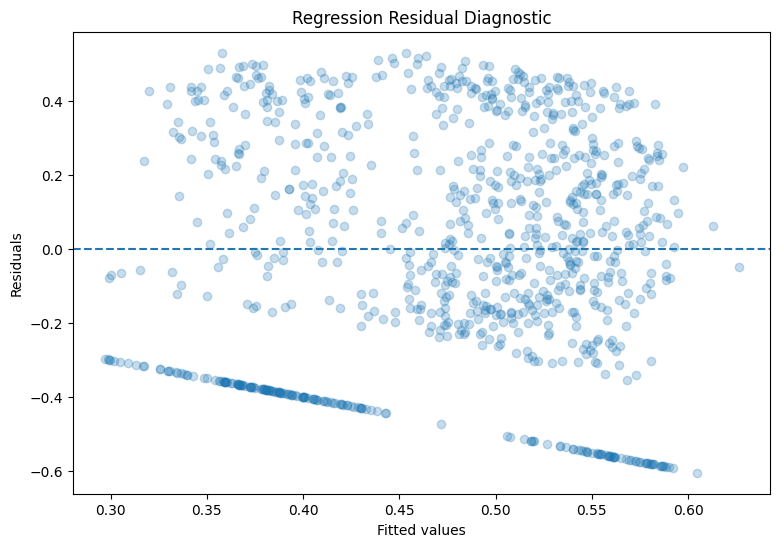

In [48]:
import matplotlib.pyplot as plt

residuals = model.resid
fitted = model.fittedvalues

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    fitted,
    residuals,
    alpha=0.25
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_xlabel(
    "Fitted values"
)

ax.set_ylabel(
    "Residuals"
)

ax.set_title(
    "Regression Residual Diagnostic"
)

plt.show()